# Bayesian Kaplan-Meier: Beta-Binomial Conjugate Model

This notebook introduces the **Bayesian nonparametric survival estimator**
implemented in `bayes_survival.nonparametric.KaplanMeierModel`.

We work through:
1. The classic (frequentist) Kaplan-Meier estimator via `lifelines`
2. The Beta-Binomial conjugate model — exact Bayesian inference, no MCMC
3. A side-by-side comparison, and why the Bayesian curve declines faster
4. How prior strength controls the degree of shrinkage


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.datasets import load_leukemia

from bayes_survival.nonparametric import KaplanMeierModel

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})


## 1. The Leukemia Dataset

The Anderson (1982) leukemia trial dataset records time to relapse for 42 patients
receiving either 6-MP (`Rx = 0`) or a placebo (`Rx = 1`).

| Column | Description |
|---|---|
| `t` | Time to relapse or censoring (weeks) |
| `status` | 1 = relapse observed, 0 = censored |
| `sex` | Patient sex (binary) |
| `logWBC` | Log white blood cell count |
| `Rx` | Treatment arm: 0 = 6-MP, 1 = placebo |


In [2]:
df = load_leukemia()

n_events = int(df["status"].sum())
print(f"Observations : {len(df)}")
print(f"Events       : {n_events} ({df['status'].mean():.1%})")
print(f"Time range   : {df['t'].min():.0f} - {df['t'].max():.0f} weeks")
df.head()

Observations : 42
Events       : 30 (71.4%)
Time range   : 1 - 35 weeks


,t,status,sex,logWBC,Rx
0,35,0,1,1.45,0
1,34,0,1,1.47,0
2,32,0,1,2.20,0
3,32,0,1,2.53,0
4,25,0,1,1.78,0


## 2. Frequentist Kaplan-Meier

The Kaplan-Meier estimator is the standard nonparametric survival curve.
At each observed event time $t_j$ it applies the product-limit formula:

$$S(t) = \prod_{t_j \leq t} \left(1 - \frac{d_j}{n_j}\right)$$

where $d_j$ is the number of events and $n_j$ the number at risk at time $t_j$.
The KM estimate is the **maximum-likelihood estimator** under no distributional
assumption. Confidence intervals (shaded below) use Greenwood's formula.


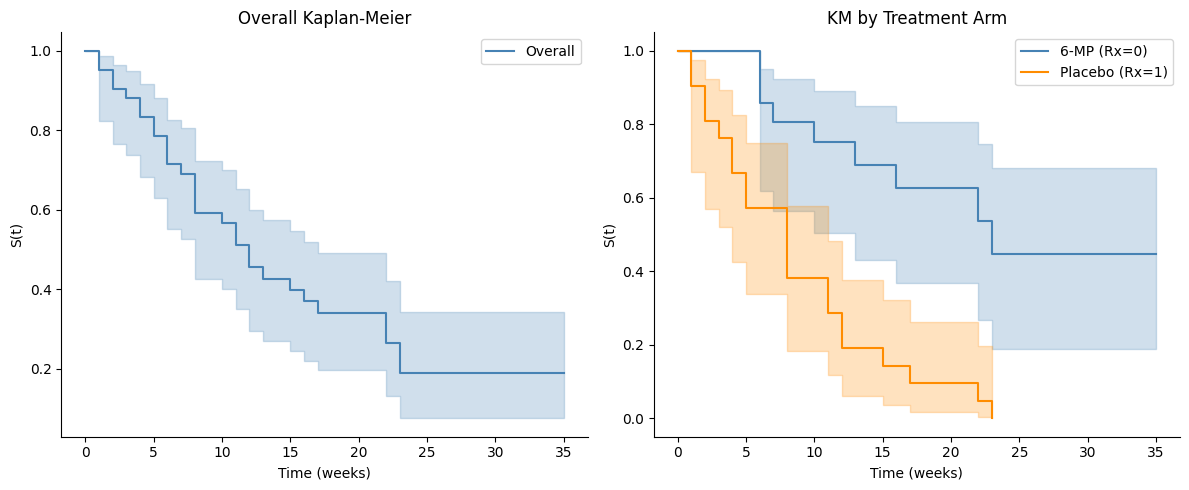

In [3]:
t     = df["t"].values
event = df["status"].values.astype(int)
eval_times = np.linspace(0, df["t"].max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall KM
ax = axes[0]
kmf_all = KaplanMeierFitter()
kmf_all.fit(t, event_observed=event, label="Overall")
kmf_all.plot_survival_function(ax=ax, ci_show=True, color="steelblue")
ax.set_title("Overall Kaplan-Meier")
ax.set_xlabel("Time (weeks)")
ax.set_ylabel("S(t)")

# Stratified by treatment
ax = axes[1]
colors = {0: "steelblue", 1: "darkorange"}
labels = {0: "6-MP (Rx=0)", 1: "Placebo (Rx=1)"}
for rx_val in [0, 1]:
    mask = df["Rx"] == rx_val
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "t"], event_observed=df.loc[mask, "status"],
            label=labels[rx_val])
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[rx_val])
ax.set_title("KM by Treatment Arm")
ax.set_xlabel("Time (weeks)")
ax.set_ylabel("S(t)")

plt.tight_layout()
plt.show()

## 3. Bayesian KM: the Beta-Binomial Conjugate

### The model

At each distinct event time $t_j$, we model the conditional hazard
$h_j = P(\text{event at } t_j \mid \text{survived to } t_j)$
as a random variable with a **Beta prior**:

| Step | Expression |
|---|---|
| Prior | $h_j \sim \mathrm{Beta}(\alpha,\, \beta)$ |
| Likelihood | $d_j \mid h_j \sim \mathrm{Binomial}(n_j,\, h_j)$ |
| Posterior | $h_j \mid \text{data} \sim \mathrm{Beta}(\alpha + d_j,\; \beta + n_j - d_j)$ |

The parameters $\alpha$ and $\beta$ act as **pseudo-counts**: $\alpha$ is the
number of virtual events and $\beta$ the number of virtual survivals injected
before observing any data.

### Why is conjugacy useful?

Because the Beta distribution is the **conjugate prior** for the Binomial
likelihood, the posterior keeps the same Beta form — updated by simple addition.
There is **no MCMC, no sampler tuning, no convergence to check**.
Posterior uncertainty bands are obtained by independently sampling
$h_j \sim \mathrm{Beta}(\alpha + d_j, \beta + n_j - d_j)$ at each event time
and multiplying the resulting $(1 - h_j)$ values.

### Posterior mean (closed form)

$$E[S(t)] = \prod_{t_j \leq t} \frac{\beta + n_j - d_j}{\alpha + \beta + n_j}$$

This follows from the independence of $h_j$ across event times in the posterior.


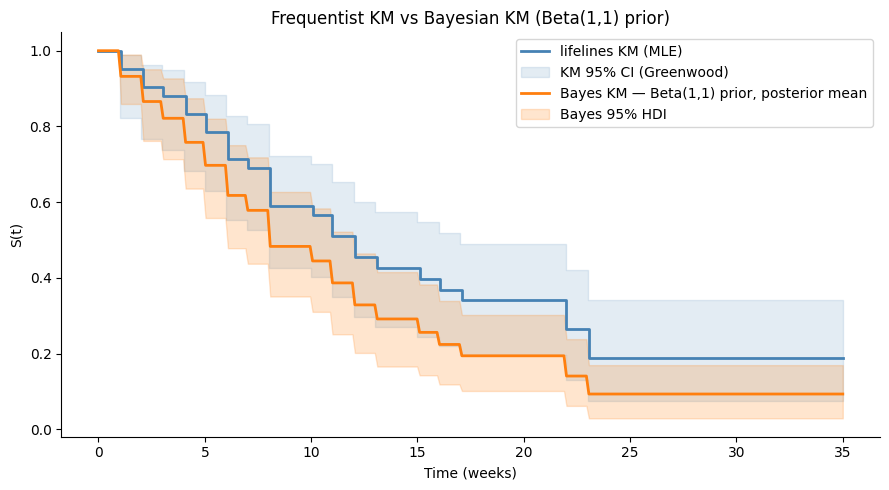

In [4]:
km_bay = KaplanMeierModel()   # Beta(1, 1) Uniform prior
km_bay.fit(t, event)

pred_km = km_bay.predict_survival_function(eval_times, hdi_prob=0.95)
km_ll_vals = kmf_all.survival_function_at_times(eval_times).values

fig, ax = plt.subplots(figsize=(9, 5))

# lifelines KM
ax.step(eval_times, km_ll_vals, where="post", lw=2, color="steelblue",
        label="lifelines KM (MLE)")
ax.fill_between(
    kmf_all.confidence_interval_.index,
    kmf_all.confidence_interval_.iloc[:, 0],
    kmf_all.confidence_interval_.iloc[:, 1],
    step="post", alpha=0.15, color="steelblue", label="KM 95% CI (Greenwood)"
)

# Bayesian KM
ax.plot(eval_times, pred_km.mean[0], lw=2, color="C1",
        label=r"Bayes KM — Beta(1,1) prior, posterior mean")
ax.fill_between(
    eval_times, pred_km.hdi_lower[0], pred_km.hdi_upper[0],
    alpha=0.20, color="C1", label="Bayes 95% HDI"
)

ax.set_xlabel("Time (weeks)")
ax.set_ylabel("S(t)")
ax.set_title("Frequentist KM vs Bayesian KM (Beta(1,1) prior)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Why Is the Bayesian Estimate More Aggressive?

Comparing the survival step formulas directly:

| Model | Survival factor at $t_j$ |
|---|---|
| KM (MLE) | $\dfrac{n_j - d_j}{n_j}$ |
| Bayesian, $\alpha = \beta = 1$ | $\dfrac{1 + n_j - d_j}{2 + n_j}$ |

The Bayesian factor is smaller (lower survival) whenever:

$$\frac{1 + n_j - d_j}{2 + n_j} < \frac{n_j - d_j}{n_j}\quad\Longleftrightarrow\quad d_j < \frac{n_j}{2}$$

In practice $d_j \ll n_j / 2$ at virtually every event time, so the Bayesian
model consistently predicts a **steeper survival decline**.

### Intuition: pseudo-counts as shrinkage toward higher hazard

The $\alpha = 1$ pseudo-event inflates the estimated hazard at each step.
Its relative impact scales as $1 / n_j$: with 42 patients at risk initially
the effect is ~2 %, but when only 5 remain at risk it inflates the hazard by
~20 %. This is why the gap widens at **late time points** — exactly where
the frequentist estimate is least reliable due to small sample size.

The table below makes the per-step difference concrete.


In [5]:
rt = km_bay._risk_table

km_factor    = (rt.n_at_risk - rt.n_events) / rt.n_at_risk
bayes_factor = (1 + rt.n_at_risk - rt.n_events) / (2 + rt.n_at_risk)

comparison = pd.DataFrame({
    "time"         : rt.times,
    "n_at_risk"    : rt.n_at_risk,
    "n_events"     : rt.n_events,
    "KM factor"    : km_factor.round(4),
    "Bayes factor" : bayes_factor.round(4),
    "diff"         : (bayes_factor - km_factor).round(4),
})
print("Survival factor per step: KM (MLE) vs Bayesian Beta(1,1)")
comparison

Survival factor per step: KM (MLE) vs Bayesian Beta(1,1)


,time,n_at_risk,n_events,KM factor,Bayes factor,diff
0,1.0,42,2,0.9524,0.9318,-0.0206
1,2.0,40,2,0.9500,0.9286,-0.0214
2,3.0,38,1,0.9737,0.9500,-0.0237
3,4.0,37,2,0.9459,0.9231,-0.0229
4,5.0,35,2,0.9429,0.9189,-0.0239
5,6.0,33,3,0.9091,0.8857,-0.0234
6,7.0,29,1,0.9655,0.9355,-0.0300
7,8.0,28,4,0.8571,0.8333,-0.0238
8,10.0,23,1,0.9565,0.9200,-0.0365
9,11.0,21,2,0.9048,0.8696,-0.0352


## 5. Effect of Prior Strength

Setting $\alpha = \beta$ keeps the prior symmetric (equal confidence in events
and survivals). Reducing their magnitude weakens the prior:

| Prior | Pseudo-counts | Character |
|---|---|---|
| Beta(1, 1) | 1 virtual event + 1 virtual survival | Uniform — default |
| Beta(0.5, 0.5) | 0.5 each | Jeffreys — optimal non-informative for Binomial |
| Beta(0.1, 0.1) | 0.1 each | Weakly informative |
| Beta(0.01, 0.01) | 0.01 each | Near-MLE |

As $\alpha, \beta \to 0$ the posterior-mean survival factor converges to
the KM step:

$$\frac{\beta + n_j - d_j}{\alpha + \beta + n_j} \;\longrightarrow\; \frac{n_j - d_j}{n_j}$$

The plot below shows the shrinkage: weaker priors hug the KM curve tightly,
while stronger priors pull the estimate down — most visibly at late time points.


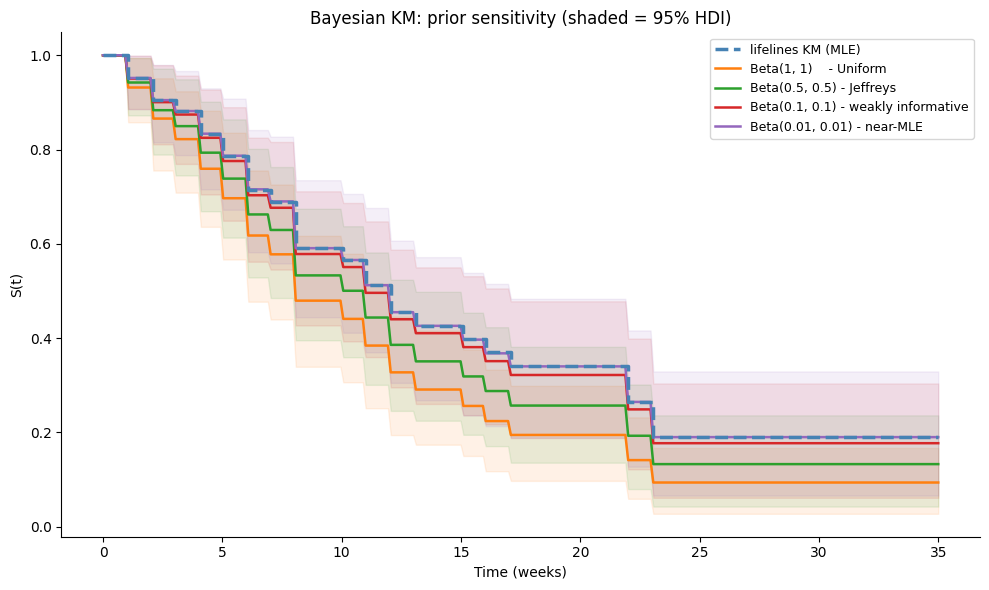

In [6]:
priors = [
    ((1.0,  1.0),  "C1", "Beta(1, 1)    - Uniform"),
    ((0.5,  0.5),  "C2", "Beta(0.5, 0.5) - Jeffreys"),
    ((0.1,  0.1),  "C3", "Beta(0.1, 0.1) - weakly informative"),
    ((0.01, 0.01), "C4", "Beta(0.01, 0.01) - near-MLE"),
]

fig, ax = plt.subplots(figsize=(10, 6))

# Frequentist KM reference
ax.step(eval_times, km_ll_vals, where="post", lw=2.5, color="steelblue",
        ls="--", label="lifelines KM (MLE)", zorder=5)

for (a, b), color, label in priors:
    km_p = KaplanMeierModel(priors={"h": (a, b)})
    km_p.fit(t, event)
    pred_p = km_p.predict_survival_function(eval_times, hdi_prob=0.95)
    ax.plot(eval_times, pred_p.mean[0], lw=1.8, color=color, label=label)
    ax.fill_between(eval_times, pred_p.hdi_lower[0], pred_p.hdi_upper[0],
                    alpha=0.10, color=color)

ax.set_xlabel("Time (weeks)")
ax.set_ylabel("S(t)")
ax.set_title("Bayesian KM: prior sensitivity (shaded = 95% HDI)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

We can also create non-symmetric priors - encoding some bias or prior knowledge of the survival. If we set $\beta$ > $\alpha$ we are telling the model

> We believe the event is less likely than survival at each time point, given the subject has already survived to that point.

The other thing implicit in this statement that's worth making noting - the prior applies identically and independently to every event time. We are not saying "overall survival is more likely than death" — we are making the same conditional claim at each $t_j$ separately. 

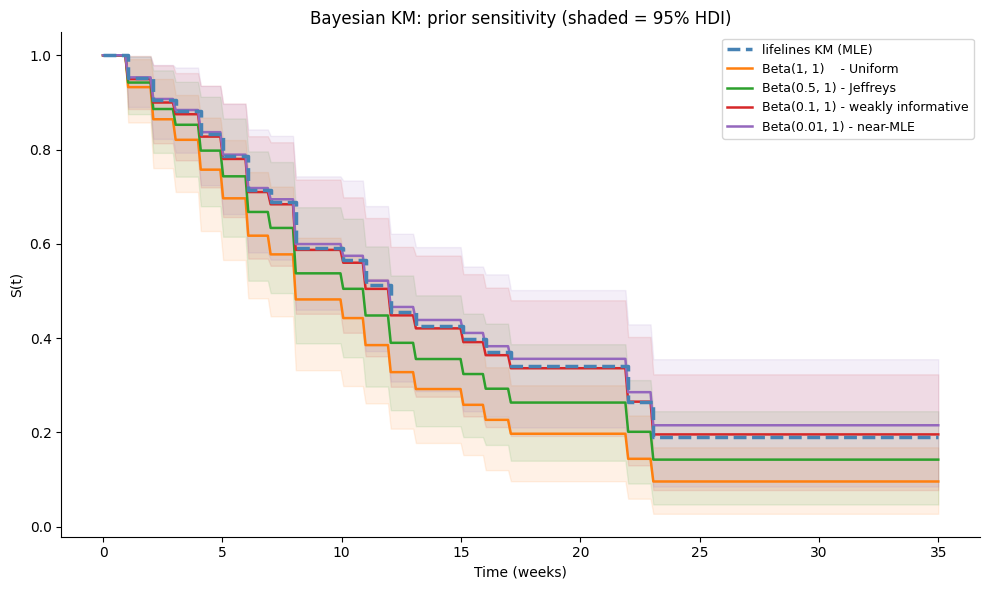

In [ ]:
priors = [
    ((1.0,  1),  "C1", "Beta(1, 1)"),
    ((0.5,  1),  "C2", "Beta(0.5, 1)"),
    ((0.1,  1),  "C3", "Beta(0.1, 1)"),
    ((0.01, 1), "C4", "Beta(0.01, 1)"),
]

fig, ax = plt.subplots(figsize=(10, 6))

# Frequentist KM reference
ax.step(eval_times, km_ll_vals, where="post", lw=2.5, color="steelblue",
        ls="--", label="lifelines KM (MLE)", zorder=5)

for (a, b), color, label in priors:
    km_p = KaplanMeierModel(priors={"h": (a, b)})
    km_p.fit(t, event)
    pred_p = km_p.predict_survival_function(eval_times, hdi_prob=0.95)
    ax.plot(eval_times, pred_p.mean[0], lw=1.8, color=color, label=label)
    ax.fill_between(eval_times, pred_p.hdi_lower[0], pred_p.hdi_upper[0],
                    alpha=0.10, color=color)

ax.set_xlabel("Time (weeks)")
ax.set_ylabel("S(t)")
ax.set_title("Bayesian KM: prior sensitivity (shaded = 95% HDI)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()